In [26]:
import numpy as np
from matplotlib import pyplot as plt

# Introduction to Ordinary Least Squares (OLS) Regression

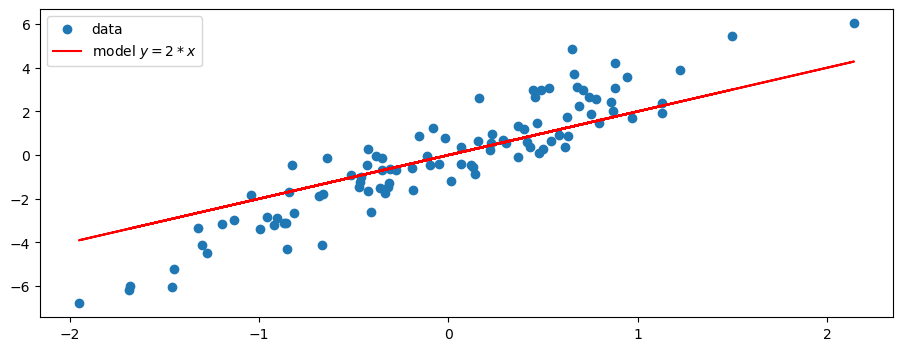

In [27]:
rng = np.random.default_rng(42)
X = rng.standard_normal(size=(100 , 1))
y = 3 * X + rng.standard_normal(size=(100 , 1))

fig, ax = plt.subplots(figsize=(11,4))
ax.scatter(X, y, label="data");
ax.plot(X, X*2, color="red", label="model $y=2*x$")
ax.legend();

When two variables are related (e.g. body weight and height), we can describe their relationship using a linear model:
$$y = \beta x + \epsilon$$
Where $x$ is the predictor, $y$ is the dependent variable, $\beta$ is the slope describing the relationship between $x$ and $y$, and $\epsilon$ is the error term.



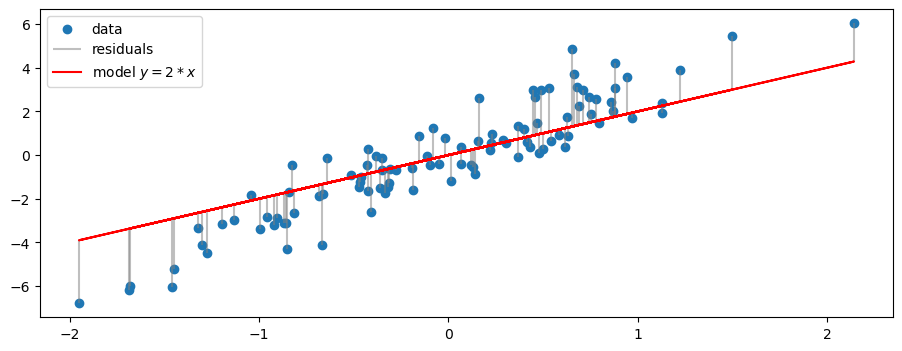

In [28]:
rng = np.random.default_rng(42)
X = rng.standard_normal(size=(100 , 1))
y = 3 * X + rng.standard_normal(size=(100 , 1))

fig, ax = plt.subplots(figsize=(11,4))
ax.scatter(X, y, label="data");
ax.vlines(X, X*2, y, color="gray", alpha=0.5, label="residuals")
ax.plot(X, X*2, color="red", label="model $y=2*x$")
ax.legend();

We can get an estimate of $\epsilon$ by computing the **residuals**: the difference between the original data $y$ and the model's prediction $\hat{y}$:

$$\hat{\epsilon} = y - \hat{y}$$

where the residuals $\hat{\epsilon}$ are an estimate of the true error term $\epsilon$

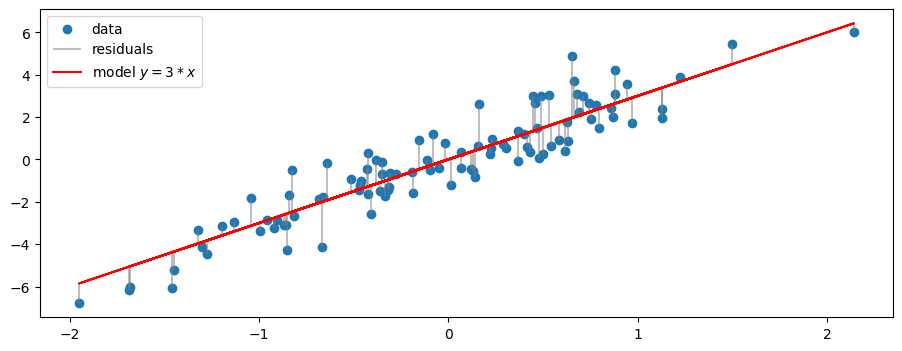

In [29]:
rng = np.random.default_rng(42)
X = rng.standard_normal(size=(100 , 1))
y = 3 * X + rng.standard_normal(size=(100 , 1))

fig, ax = plt.subplots(figsize=(11,4))
ax.scatter(X, y, label="data");
ax.vlines(X, X*3, y, color="gray", alpha=0.5, label="residuals")
ax.plot(X, X*3, color="red", label="model $y=3*x$")
ax.legend();

To find the best fitting model, we calculate the slope $\beta$ so that the sum of squared residuals is minimized. This is called ordinary least-squares (OLS) regression.

$$\hat{\beta} = \underset{\beta}{\arg\min} \sum_{i=1}^{n}\hat{\epsilon}i^2$$

In the example, this is the case for $\hat{\beta}=3$


In [30]:
print()

When we have more than two variables (e.g. body weight, height and age), we can write the equation in matrix form:

$$ y = X\beta$$

with

$$X = \begin{bmatrix} x_{11} & \cdots & x_{1p} \\\\ \vdots & \ddots & \vdots \\\\ x_{n1} & \cdots & x_{np} \end{bmatrix}, \beta=\begin{bmatrix} \beta_1 \\\\ \vdots \\\\ \beta_p \end{bmatrix}, y = \begin{bmatrix} y_1 \\\\ \vdots \\\\ y_n \end{bmatrix}$$


In [31]:
print()

To solve the OLS regression, we first expand the squared residuals

$$\hat{\beta} = \underset{\beta}{\arg\min} \| y - X\beta \|^2$$


$$\|y - X\beta\|^2 = (y - X\beta)^T(y - X\beta) = y^Ty - 2\beta^TX^Ty + \beta^TX^TX\beta$$


In [32]:
print()

To solve the OLS regression, we first expand the squared residuals

$$\hat{\beta} = \underset{\beta}{\arg\min} \| y - X\beta \|^2$$


$$\|y - X\beta\|^2 = (y - X\beta)^T(y - X\beta) = y^Ty - 2\beta^TX^Ty + \beta^TX^TX\beta$$

And then take the derivative with respect to $\beta$ and set it to zero to minimize them

$$\frac{\partial}{\partial \beta}\left[y^Ty - 2\beta^TX^Ty + \beta^TX^TX\beta\right] = -2X^Ty + 2X^TX\beta = 0$$


In [33]:
print()

To solve the OLS regression, we first expand the squared residuals

$$\hat{\beta} = \underset{\beta}{\arg\min} \| y - X\beta \|^2$$


$$\|y - X\beta\|^2 = (y - X\beta)^T(y - X\beta) = y^Ty - 2\beta^TX^Ty + \beta^TX^TX\beta$$

And then take the derivative with respect to $\beta$ and set it to zero to minimize them

$$\frac{\partial}{\partial \beta}\left[y^Ty - 2\beta^TX^Ty + \beta^TX^TX\beta\right] = -2X^Ty + 2X^TX\beta = 0$$

Finally, we rearrange the result

$$X^TX\beta = X^Ty$$

Which is a linear system of equations that can be solved in NumPy 

```python
beta = np.linalg.solve(X.T @ X, X.T @ y)
```

# Ridge Regularization

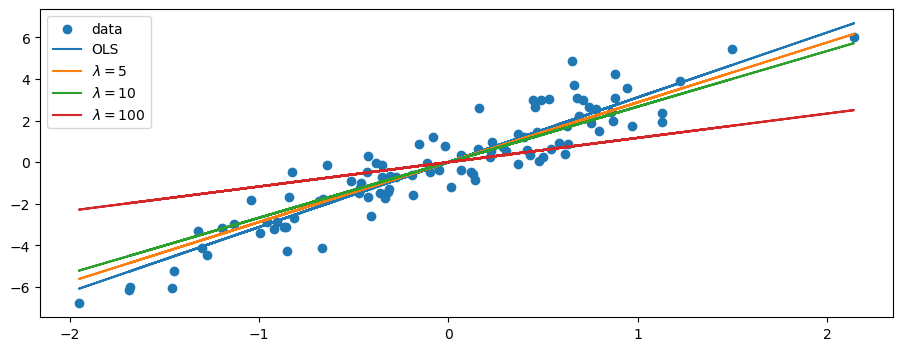

In [34]:
rng = np.random.default_rng(42)
X = rng.standard_normal(size=(100 , 1))
y = 3 * X + rng.standard_normal(size=(100 , 1))
beta = np.linalg.solve(X.T @ X, X.T @ y)
fig, ax = plt.subplots(figsize=(11,4))
plt.scatter(X, y, label="data");
plt.plot(X, X*beta, label="OLS")

for i, lam in enumerate([5, 10, 100]):
    beta = np.linalg.solve(X.T @ X + lam * np.eye(X.shape[1]), X.T @ y)
    plt.plot(X, X*beta, label=f"$\\lambda={lam}$", color=f"C{i+1}")

plt.legend();


OLS is prone to **overfitting** to the sample and will perform worse on unseen data.  **Ridge** regression addresses this by adding a penalty term $\lambda$ to the objective:

$$\hat{\beta} = \underset{\beta}{\arg\min} |y - X\beta|^2 + \lambda|\beta|^2$$

This penalizes large values of $\beta$ - the higher $\lambda$ the heavier the penalty.
